# Install and Import Modules

In [1]:
!pip uninstall -y torch torchvision torchaudio torchcodec

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124


In [2]:
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip install -q torchcodec==0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 15.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 10.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install timm

In [4]:
# !pip install "ffmpeg<8"

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from datasets import load_dataset
from typing import Optional
from tensorflow import keras
from keras import layers
from keras import regularizers
from keras.optimizers import Adam
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import numpy as np
import cv2
import timm
from huggingface_hub import login

2025-10-23 07:48:36.039845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761205716.223559      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761205716.279564      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

In [6]:
login()

In [7]:
from torchcodec._frame import AudioSamples

In [8]:
import torchcodec
print("torchcodec version:", torchcodec.__version__)
import inspect
print("torchcodec module file:", inspect.getfile(torchcodec))


torchcodec version: 0.8.0
torchcodec module file: /usr/local/lib/python3.11/dist-packages/torchcodec/__init__.py


In [9]:
import torch
torch.__version__

'2.9.0+cu126'

# Load Data

In [44]:
dataset = load_dataset("nexar-ai/nexar_collision_prediction", split="train", drop_labels=False)

Resolving data files:   0%|          | 0/1502 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1348 [00:00<?, ?it/s]

In [45]:
test_dataset = load_dataset("nexar-ai/nexar_collision_prediction", split="test", drop_labels=False)

Resolving data files:   0%|          | 0/1502 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1348 [00:00<?, ?it/s]

In [17]:
dataset

Dataset({
    features: ['video', 'time_of_event', 'time_of_alert', 'light_conditions', 'weather', 'scene', 'time_to_accident'],
    num_rows: 1500
})

## Exploring Data

In [11]:
def plot(frames: torch.Tensor, title : Optional[str] = None):
    """
    Plot a batch of frames.
    Args:
        frames: A batch of frames.
        title: A title for the plot.
    """
    try:
        from torchvision.utils import make_grid
        from torchvision.transforms.v2.functional import to_pil_image
        import matplotlib.pyplot as plt
    except ImportError:
        print("Cannot plot, please run `pip install torchvision matplotlib`")
        return

    plt.rcParams["savefig.bbox"] = 'tight'
    fig, ax = plt.subplots()
    ax.imshow(to_pil_image(make_grid(frames)))
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    if title is not None:
        ax.set_title(title)
    plt.tight_layout()

In [12]:
decoder = dataset['video'][0]
time_of_event = dataset['time_of_event'][0]

In [13]:
time_of_event

In [14]:
print(decoder.metadata)

VideoStreamMetadata:
  duration_seconds_from_header: 40.0
  begin_stream_seconds_from_header: 0.0
  bit_rate: 4717201.0
  codec: h264
  stream_index: 0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 40.0
  width: 1280
  height: 720
  num_frames_from_header: 1200
  num_frames_from_content: 1200
  average_fps_from_header: 30.0
  pixel_aspect_ratio: 0
  duration_seconds: 40.0
  begin_stream_seconds: 0.0
  end_stream_seconds: 40.0
  num_frames: 1200
  average_fps: 30.0



In [15]:
type(decoder)

torchcodec.decoders._video_decoder.VideoDecoder

In [16]:
first_frame = decoder[0]  # using a single int index
every_twenty_frame = decoder[0 : -1 : 20]  # using slices

print(f"{first_frame.shape = }")
print(f"{first_frame.dtype = }")
print(f"{every_twenty_frame.shape = }")
print(f"{every_twenty_frame.dtype = }")

first_frame.shape = torch.Size([3, 720, 1280])
first_frame.dtype = torch.uint8
every_twenty_frame.shape = torch.Size([60, 3, 720, 1280])
every_twenty_frame.dtype = torch.uint8


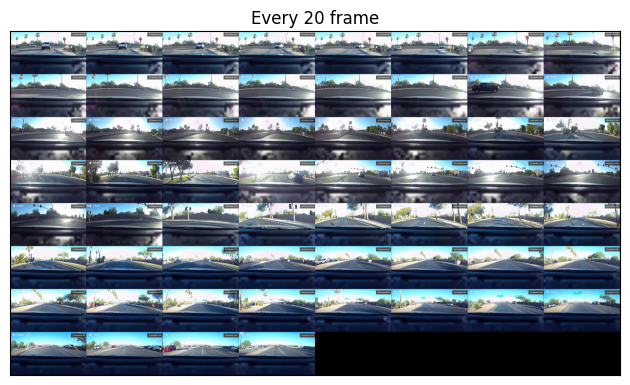

In [17]:
plot(every_twenty_frame, "Every 20 frame")

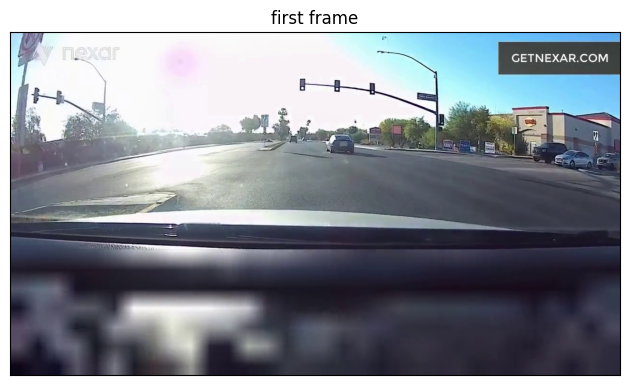

In [18]:
plot(decoder[587], "first frame")

In [19]:
decoder[0]

tensor([[[127, 127, 128,  ..., 251, 251, 251],
         [129, 130, 130,  ..., 251, 251, 251],
         [134, 132, 132,  ..., 251, 251, 251],
         ...,
         [ 43,  43,  43,  ..., 148, 148, 148],
         [ 43,  43,  43,  ..., 148, 148, 148],
         [ 43,  43,  43,  ..., 148, 148, 148]],

        [[225, 225, 226,  ..., 251, 251, 251],
         [227, 228, 228,  ..., 251, 251, 251],
         [232, 230, 230,  ..., 251, 251, 251],
         ...,
         [ 47,  47,  47,  ..., 160, 160, 160],
         [ 47,  47,  47,  ..., 160, 160, 160],
         [ 47,  47,  47,  ..., 160, 160, 160]],

        [[247, 247, 248,  ..., 251, 251, 251],
         [249, 250, 250,  ..., 251, 251, 251],
         [254, 252, 252,  ..., 251, 251, 251],
         ...,
         [ 78,  78,  78,  ..., 168, 168, 168],
         [ 78,  78,  78,  ..., 168, 168, 168],
         [ 78,  78,  78,  ..., 168, 168, 168]]], dtype=torch.uint8)

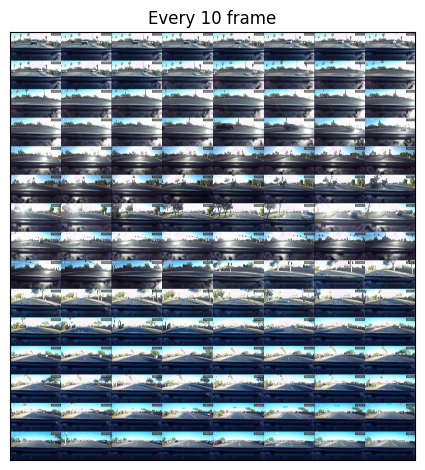

In [20]:
every_ten_frame = decoder[0 : -1 : 10]  # using slices
plot(every_ten_frame, "Every 10 frame")

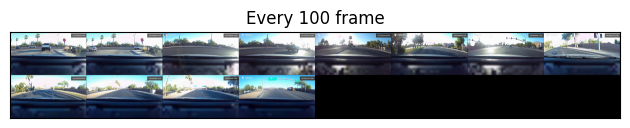

In [21]:
every_100_frame = decoder[0 : -1 : 100]  # using slices
plot(every_100_frame, "Every 100 frame")

In [22]:
dataset.to_pandas()['time_of_event'].median()

,video,time_of_event,time_of_alert,light_conditions,weather,scene,time_to_accident
0,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Clear,Sub-urban,NaN
1,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Rain,Urban,NaN
2,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Cloudy,Urban,NaN
3,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Clear,Urban,NaN
4,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Clear,Sub-urban,NaN
...,...,...,...,...,...,...,...
1495,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.933,18.633,Normal,Clear,Urban,NaN
1496,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.567,19.033,Normal,Clear,Urban,NaN
1497,"{'bytes': None, 'path': '/root/.cache/huggingf...",17.900,13.933,Normal,Clear,Highway,NaN
1498,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.867,19.267,Normal,Clear,Urban,NaN


In [23]:
frame_shape = first_frame.shape
frame_shape

torch.Size([3, 720, 1280])

In [24]:
del every_100_frame, every_ten_frame, every_twenty_frame

## Preprocess Data

In [18]:
dataset.to_pandas()['time_of_event'].describe()

count    750.000000
mean      19.101628
std        3.565120
min        3.032000
25%       19.133000
50%       19.802000
75%       20.333000
max       56.800000
Name: time_of_event, dtype: float64

In [19]:
min_time_of_event = dataset.to_pandas()['time_of_event'].min()
max_time_of_event = dataset.to_pandas()['time_of_event'].max()

In [ ]:
max_frames = 0
min_frames = 100000
for video in dataset['video']:
  min_frames = min(min_frames, video.metadata.num_frames)
  max_frames = max(max_frames, video.metadata.num_frames)
print(min_frames)
print(max_frames)

420
1800


In [ ]:
video = dataset[0]["video"]
print(video)
frames = np.array(video)
for frame in frames:
  print(frame.shape)
  print(frame.dtype)
  print(frame.max())
  print(frame.min())
  break

(3, 720, 1280)
uint8
255
0


In [ ]:
frames.shape

(1200, 3, 720, 1280)

In [34]:
MAX_FRAMES = 32
RESIZE = (160, 160)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [43]:
class AccidentVideoDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, max_frames=MAX_FRAMES, resize=RESIZE, min_time_of_event=min_time_of_event, max_time_of_event=max_time_of_event):
        self.hf_dataset = hf_dataset
        self.max_frames = max_frames
        self.resize = resize
        self.min_time_of_event = min_time_of_event
        self.max_time_of_event = max_time_of_event

    def __len__(self):
        return len(self.hf_dataset)

    def preprocess_video(self, frames):
        meta = frames.metadata
        num_frames = int(meta.num_frames)
        duration_s = float(meta.duration_seconds)

        fps = max(1, int(round(num_frames / duration_s)))

        # select frames
        start = max(0, int(self.min_time_of_event*fps))
        end = min(num_frames, int(self.max_time_of_event*fps))
        if start > end:
            start = 0

        step = max(1, int((end - start) / self.max_frames))
        selected = frames[start:end:step]

        np_frames = []
        for f in selected:
            frame = f.permute(1, 2, 0).numpy()
            frame = cv2.resize(frame, self.resize, interpolation=cv2.INTER_AREA)
            frame = frame.astype(np.float32) / 255.0
            np_frames.append(frame)

        # pad/truncate
        if len(np_frames) == 0:
            np_frames = [np.zeros((self.resize[1], self.resize[0], 3), dtype=np.float32)] * self.max_frames
        elif len(np_frames) < self.max_frames:
            pad = self.max_frames - len(np_frames)
            np_frames.extend([np.zeros_like(np_frames[0])] * pad)
        elif len(np_frames) > self.max_frames:
            np_frames = np_frames[:self.max_frames]

        np_frames = np.stack(np_frames)  # (T, H, W, 3)
        np_frames = np.transpose(np_frames, (0, 3, 1, 2))  # (T, 3, H, W)
        return torch.tensor(np_frames, dtype=torch.float32)

    def __getitem__(self, idx):
        ex = self.hf_dataset[idx]
        frames = ex["video"]
        time_of_event = ex.get("time_of_event", None)
        label = 1 if time_of_event is not None else 0
        frames_tensor = self.preprocess_video(frames)
        return frames_tensor, torch.tensor(label, dtype=torch.long)


# Create Model

In [46]:
class CNNLSTM_EfficientNet(nn.Module):
    def __init__(self, model_name="efficientnet_b0", num_classes=2, hidden_dim=256):
        super().__init__()
        # load pretrained EfficientNet from timm
        self.cnn = timm.create_model(model_name, pretrained=True, features_only=True)
        cnn_feature_dim = self.cnn.feature_info[-1]['num_chs']

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.lstm = nn.LSTM(input_size=cnn_feature_dim,
                            hidden_size=hidden_dim,
                            num_layers=1,
                            batch_first=True)
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        with torch.no_grad():  # freeze EfficientNet
            feats = self.cnn(x)[-1]
            feats = self.avgpool(feats)
            feats = feats.view(B, T, -1)
        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out


In [47]:
batch_size = 16
size_of_dataset = len(dataset)
size_of_test = len(test_dataset)

dataset = AccidentVideoDataset(dataset)
train_data, valid_data = random_split(dataset, [int(size_of_dataset*0.8), int(size_of_dataset*0.2)])
size_of_train = len(train_data)
size_of_valid = len(valid_data)

test_ds = AccidentVideoDataset(test_dataset)

In [48]:
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True
)

valid_loader = torch.utils.data.DataLoader(
    valid_data,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True
)

# Training

In [ ]:
from tqdm import tqdm
PATH = './model_lstm.pth'
model = CNNLSTM_EfficientNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 5
losses = []
accuracies = []

valid_losses = []
valid_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    progress_bar = tqdm(total=int(size_of_train/batch_size))
    progress_bar.set_description(f"Epoch {epoch+1}")

    for videos, labels in train_loader:
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * videos.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({"loss": total_loss / total})
        progress_bar.update(1)

    acc = total_correct / total
    total_loss = total_loss/total
    accuracies.append((acc))
    losses.append(total_loss)
    progress_bar.close()

    print(f"Epoch {epoch+1}: loss={total_loss:.4f}, accuracy={acc:.3f}")
    torch.save(model.state_dict(), PATH)

    model.eval()
    with torch.no_grad():
        for videos, labels in tqdm(valid_loader, total=int(size_of_valid/batch_size)):
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * videos.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = total_correct / total
    total_loss = total_loss/total
    valid_accuracies.append((acc))
    valid_losses.append(total_loss)
    print(f"Epoch {epoch+1}: valid loss={total_loss:.4f}, valid accuracy={acc:.3f}")



Epoch 1:   0%|          | 0/75 [04:51<?, ?it/s]

Epoch 1: 100%|██████████| 75/75 [38:07<00:00, 30.50s/it, loss=0.695]


Epoch 1: loss=0.6948, accuracy=0.513


19it [09:59, 31.54s/it]                        


Epoch 1: valid loss=0.1365, valid accuracy=0.527


Epoch 2: 100%|██████████| 75/75 [37:57<00:00, 30.37s/it, loss=0.672]  


...

Epoch 4: valid loss=0.1296, valid accuracy=0.689


Epoch 5: 100%|██████████| 75/75 [37:48<00:00, 30.24s/it, loss=0.568]  


Epoch 5: loss=0.5679, accuracy=0.743


19it [09:58, 31.51s/it]                        

Epoch 5: valid loss=0.1290, valid accuracy=0.717


In [53]:
def plot_metrics(losses, accuracies):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), losses)
    plt.xlabel("Epochs")
    plt.ylabel("loss")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("accuracy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

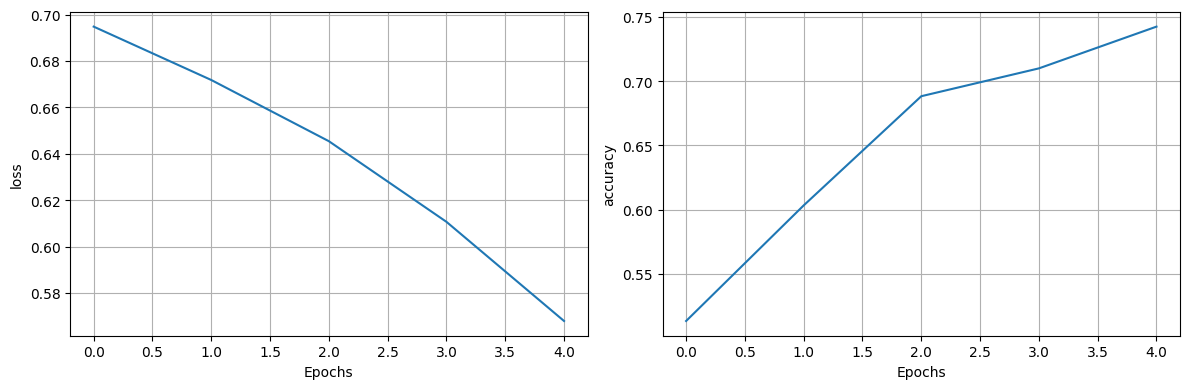

In [54]:
plot_metrics(losses, accuracies)

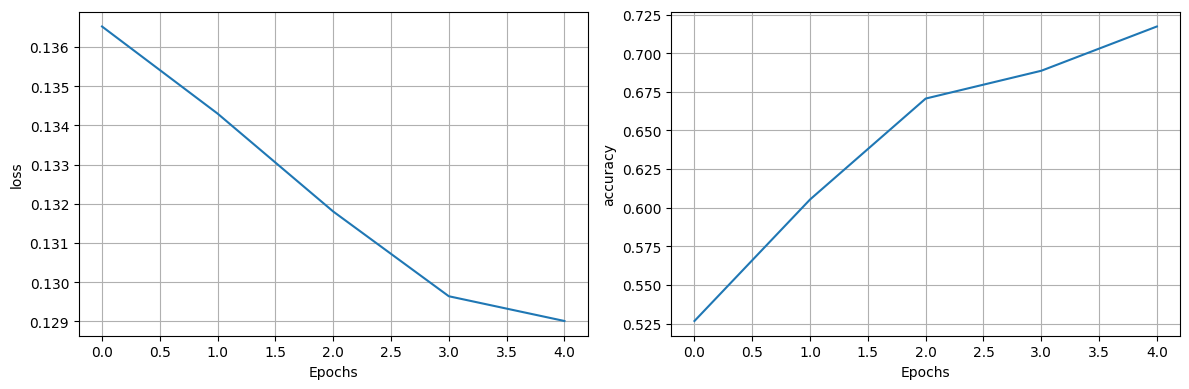

In [55]:
plot_metrics(valid_losses, valid_accuracies)

In [56]:
model.eval()
with torch.no_grad():
    total_correct, total = 0, 0
    for videos, labels in tqdm(test_loader, total=int(size_of_test/batch_size)):
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        outputs = model(videos)

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = total_correct / total

    print(f"Accuracy={acc:.3f}")

100%|██████████| 84/84 [13:24<00:00,  9.58s/it]

Accuracy=0.627
